# Masked Attention Variant Visualization

This notebook visualizes the directional attention policy for masked-token training:

- masked queries can attend to unmasked keys/values
- unmasked queries cannot attend to masked keys/values

using real GeMS TFRecord data.


In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print("Project root:", ROOT)

Project root: /home/wuhao/spectra-learning


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch

from configs.gems_a_masked_latent_index import get_config
from input_pipeline import TfLightningDataModule, _build_dataset
from networks.transformer_torch import build_masked_attention_allow_matrix

In [3]:
cfg = get_config()
cfg.tfrecord_dir = "/home/wuhao/spectra-learning/data/gems_peaklist_tfrecord"

dm = TfLightningDataModule(cfg, seed=42)

aug_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=8,
    shuffle_buffer=1000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    augmentation_type="multicrop",
    multicrop_num_local_views=cfg.multicrop_num_local_views,
    multicrop_global_keep_fraction=1.0,
    multicrop_local_keep_fraction=cfg.multicrop_local_keep_fraction,
    mz_jitter_std=cfg.sigreg_mz_jitter_std,
    intensity_jitter_std=cfg.sigreg_intensity_jitter_std,
    keep_masked_tokens=cfg.multicrop_keep_masked_tokens,
    peak_ordering=cfg.peak_ordering,
)

batch = next(aug_ds.as_numpy_iterator())
print("Batch keys:", sorted(batch.keys()))
print("fused_mz shape:", batch["fused_mz"].shape)

Batch keys: ['fused_intensity', 'fused_masked_positions', 'fused_mz', 'fused_precursor_mz', 'fused_valid_mask', 'intensity', 'mz', 'peak_intensity', 'peak_mz', 'peak_valid_mask', 'precursor_mz', 'rt', 'view1_masked_fraction']
fused_mz shape: (48, 60)


In [4]:
masked_rows = np.where(batch["fused_masked_positions"].any(axis=1))[0]
row = int(masked_rows[0])

valid = batch["fused_valid_mask"][row].astype(bool)
masked = batch["fused_masked_positions"][row].astype(bool)
mz = batch["fused_mz"][row]
intensity = batch["fused_intensity"][row]

print("Selected fused row:", row)
print("num_valid:", int(valid.sum()))
print("num_masked:", int(masked.sum()))
print("num_unmasked_valid:", int((valid & ~masked).sum()))

Selected fused row: 0
num_valid: 60
num_masked: 15
num_unmasked_valid: 45


In [5]:
padding_allow = np.logical_and(valid[:, None], valid[None, :])
variant_allow = build_masked_attention_allow_matrix(
    torch.from_numpy(valid[None, :]),
    torch.from_numpy(masked[None, :]),
)[0].numpy()

blocked_edges = np.logical_and(padding_allow, ~variant_allow)

unmasked_q = (~masked)[:, None]
masked_k = masked[None, :]
expected_blocked_pattern = np.logical_and(
    np.logical_and(unmasked_q, masked_k),
    padding_allow,
)

print("padding edges:", int(padding_allow.sum()))
print("variant edges:", int(variant_allow.sum()))
print("blocked edges:", int(blocked_edges.sum()))
print(
    "blocked pattern matches expectation:",
    bool(np.array_equal(blocked_edges, expected_blocked_pattern)),
)

padding edges: 3600
variant edges: 2925
blocked edges: 675
blocked pattern matches expectation: True


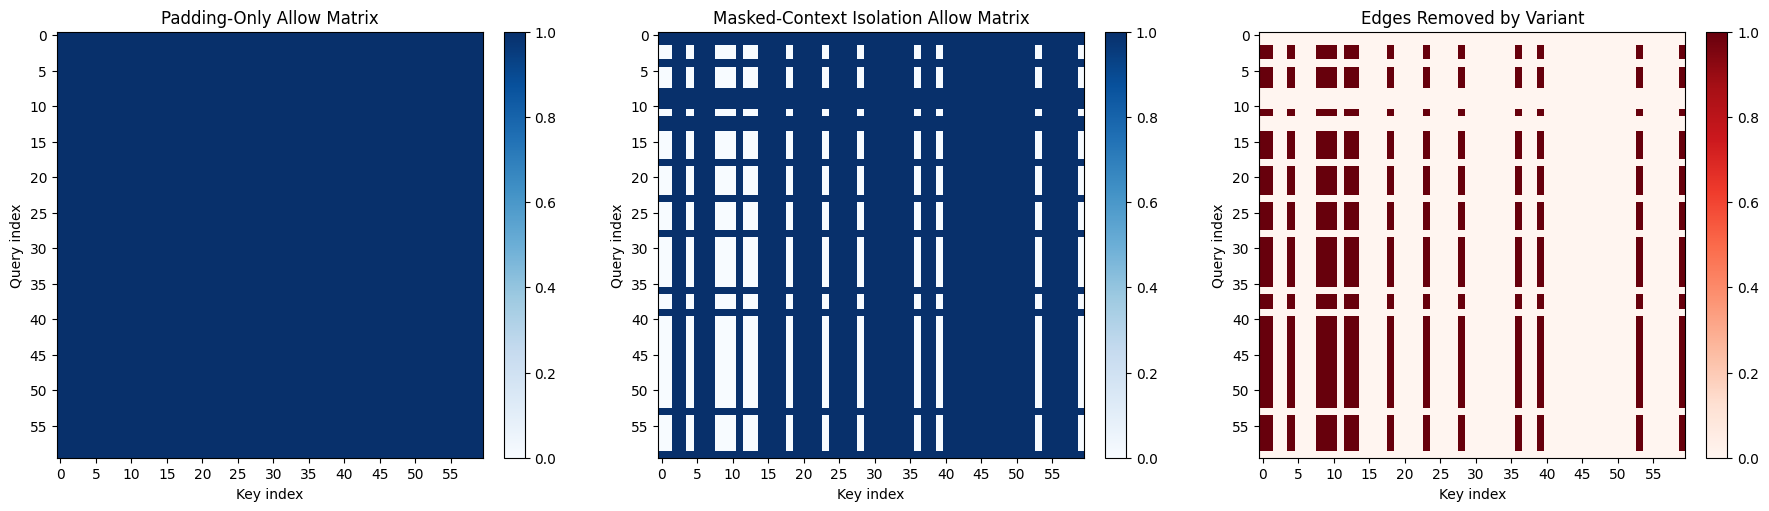

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].imshow(padding_allow.astype(float), vmin=0, vmax=1, cmap="Blues")
axes[0].set_title("Padding-Only Allow Matrix")
axes[0].set_xlabel("Key index")
axes[0].set_ylabel("Query index")

im1 = axes[1].imshow(variant_allow.astype(float), vmin=0, vmax=1, cmap="Blues")
axes[1].set_title("Masked-Context Isolation Allow Matrix")
axes[1].set_xlabel("Key index")
axes[1].set_ylabel("Query index")

im2 = axes[2].imshow(blocked_edges.astype(float), vmin=0, vmax=1, cmap="Reds")
axes[2].set_title("Edges Removed by Variant")
axes[2].set_xlabel("Key index")
axes[2].set_ylabel("Query index")

for ax in axes:
    ax.set_xticks(np.arange(0, len(valid), 5))
    ax.set_yticks(np.arange(0, len(valid), 5))

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.savefig("notebooks/fig_masked_attention_variant_matrices.png", bbox_inches="tight")
plt.show()

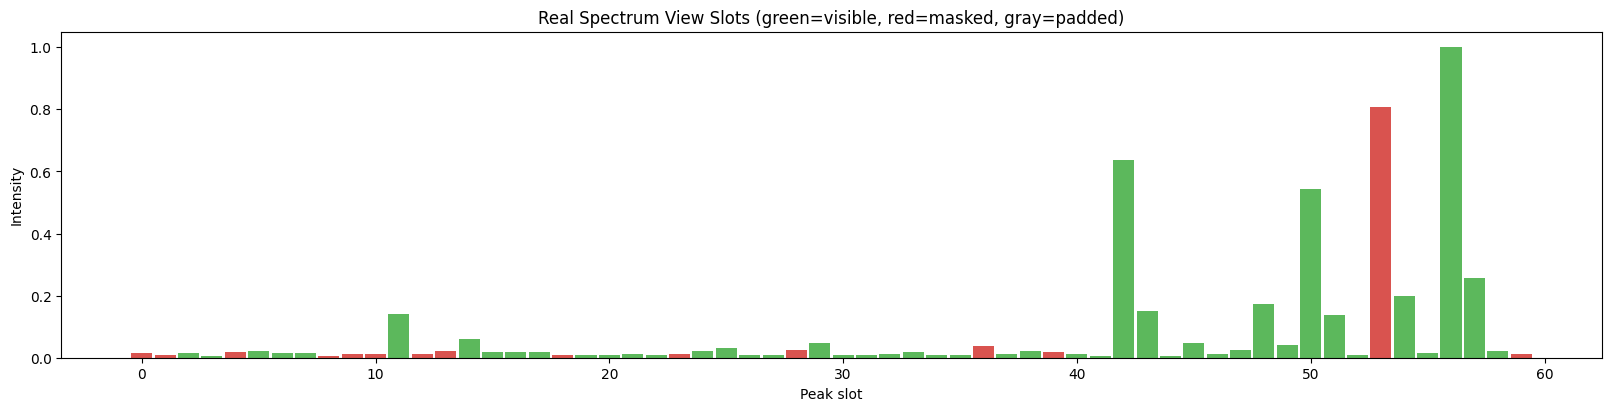

In [7]:
slot = np.arange(len(valid))
colors = np.where(~valid, "#bbbbbb", np.where(masked, "#d9534f", "#5cb85c"))
labels = np.where(~valid, "padded", np.where(masked, "masked", "visible"))

fig, ax = plt.subplots(figsize=(16, 4), constrained_layout=True)
ax.bar(slot, intensity, color=colors, width=0.9)
ax.set_title("Real Spectrum View Slots (green=visible, red=masked, gray=padded)")
ax.set_xlabel("Peak slot")
ax.set_ylabel("Intensity")

plt.savefig("notebooks/fig_masked_attention_variant_slots.png", bbox_inches="tight")
plt.show()